In [1]:
import pandas as pd 
import json

In [ ]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()


In [ ]:
from huggingface_hub import login



In [4]:
from datasets import load_dataset

dataset_hf = load_dataset("yymYYM/stock_trading_QA")
dataset_hf

README.md:   0%|          | 0.00/114 [00:00<?, ?B/s]

stock_trading_qa_pairs_processed.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/7165 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Unnamed: 0', 'question', 'answer'],
        num_rows: 7165
    })
})

In [5]:
json_data = pd.read_json("/kaggle/input/datasets/xasantursunboyev/json-data/one.json")
print(json_data.head())

               dataset                                        description  \
0  us_stock_trading_qa  3000 Q&A pairs for US stock market trading and...   
1  us_stock_trading_qa  3000 Q&A pairs for US stock market trading and...   
2  us_stock_trading_qa  3000 Q&A pairs for US stock market trading and...   
3  us_stock_trading_qa  3000 Q&A pairs for US stock market trading and...   
4  us_stock_trading_qa  3000 Q&A pairs for US stock market trading and...   

                                               pairs  
0  {'id': 0, 'question': 'What is the Pattern Day...  
1  {'id': 1, 'question': 'How are short-term and ...  
2  {'id': 2, 'question': 'What is the wash-sale r...  
3  {'id': 3, 'question': 'What are the main diffe...  
4  {'id': 4, 'question': 'How does dollar-cost av...  


In [6]:
json_data.to_csv("clean_data.csv", sep = "|", index = False )
clean_data = pd.read_csv("clean_data.csv", sep = "|")
clean_data.tail()

,dataset,description,pairs
381,us_stock_trading_qa,3000 Q&A pairs for US stock market trading and...,"{'id': 46, 'question': 'What is interest rate?..."
382,us_stock_trading_qa,3000 Q&A pairs for US stock market trading and...,"{'id': 47, 'question': 'What is GDP?', 'answer..."
383,us_stock_trading_qa,3000 Q&A pairs for US stock market trading and...,"{'id': 48, 'question': 'What is a trading bot?..."
384,us_stock_trading_qa,3000 Q&A pairs for US stock market trading and...,"{'id': 49, 'question': 'What is overfitting?',..."
385,us_stock_trading_qa,3000 Q&A pairs for US stock market trading and...,"{'id': 50, 'question': 'What is drawdown?', 'a..."


In [7]:
clean_data = clean_data.rename(columns = {"Unnamed: 0":"Index"})
clean_data.head()

,dataset,description,pairs
0,us_stock_trading_qa,3000 Q&A pairs for US stock market trading and...,"{'id': 0, 'question': 'What is the Pattern Day..."
1,us_stock_trading_qa,3000 Q&A pairs for US stock market trading and...,"{'id': 1, 'question': 'How are short-term and ..."
2,us_stock_trading_qa,3000 Q&A pairs for US stock market trading and...,"{'id': 2, 'question': 'What is the wash-sale r..."
3,us_stock_trading_qa,3000 Q&A pairs for US stock market trading and...,"{'id': 3, 'question': 'What are the main diffe..."
4,us_stock_trading_qa,3000 Q&A pairs for US stock market trading and...,"{'id': 4, 'question': 'How does dollar-cost av..."


In [8]:
clean_data = clean_data.drop("dataset", axis = "columns")
clean_data

,description,pairs
0,3000 Q&A pairs for US stock market trading and...,"{'id': 0, 'question': 'What is the Pattern Day..."
1,3000 Q&A pairs for US stock market trading and...,"{'id': 1, 'question': 'How are short-term and ..."
2,3000 Q&A pairs for US stock market trading and...,"{'id': 2, 'question': 'What is the wash-sale r..."
3,3000 Q&A pairs for US stock market trading and...,"{'id': 3, 'question': 'What are the main diffe..."
4,3000 Q&A pairs for US stock market trading and...,"{'id': 4, 'question': 'How does dollar-cost av..."
...,...,...
381,3000 Q&A pairs for US stock market trading and...,"{'id': 46, 'question': 'What is interest rate?..."
382,3000 Q&A pairs for US stock market trading and...,"{'id': 47, 'question': 'What is GDP?', 'answer..."
383,3000 Q&A pairs for US stock market trading and...,"{'id': 48, 'question': 'What is a trading bot?..."
384,3000 Q&A pairs for US stock market trading and...,"{'id': 49, 'question': 'What is overfitting?',..."


In [9]:
clean_data = clean_data.drop("description", axis = "columns")
clean_data

,pairs
0,"{'id': 0, 'question': 'What is the Pattern Day..."
1,"{'id': 1, 'question': 'How are short-term and ..."
2,"{'id': 2, 'question': 'What is the wash-sale r..."
3,"{'id': 3, 'question': 'What are the main diffe..."
4,"{'id': 4, 'question': 'How does dollar-cost av..."
...,...
381,"{'id': 46, 'question': 'What is interest rate?..."
382,"{'id': 47, 'question': 'What is GDP?', 'answer..."
383,"{'id': 48, 'question': 'What is a trading bot?..."
384,"{'id': 49, 'question': 'What is overfitting?',..."


In [10]:
clean_data.head()

,pairs
0,"{'id': 0, 'question': 'What is the Pattern Day..."
1,"{'id': 1, 'question': 'How are short-term and ..."
2,"{'id': 2, 'question': 'What is the wash-sale r..."
3,"{'id': 3, 'question': 'What are the main diffe..."
4,"{'id': 4, 'question': 'How does dollar-cost av..."


In [11]:
# Fix — use ast.literal_eval to convert string → dict first:
import ast

# Convert string to actual dict
clean_data['pairs'] = clean_data['pairs'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)


clean_data['id'] = clean_data['pairs'].apply(lambda x: x.get('id'))
clean_data['question'] = clean_data['pairs'].apply(lambda x: x.get('question'))
clean_data['answer'] = clean_data['pairs'].apply(lambda x: x.get('answer'))
clean_data.head()

,pairs,id,question,answer
0,"{'id': 0, 'question': 'What is the Pattern Day...",0,What is the Pattern Day Trader (PDT) rule in t...,The PDT rule applies to margin accounts under ...
1,"{'id': 1, 'question': 'How are short-term and ...",1,How are short-term and long-term capital gains...,Short-term gains (held 1 year or less) are tax...
2,"{'id': 2, 'question': 'What is the wash-sale r...",2,What is the wash-sale rule and how does it aff...,The wash-sale rule disallows a tax loss if you...
3,"{'id': 3, 'question': 'What are the main diffe...",3,What are the main differences between NYSE and...,NYSE is an auction market with a physical floo...
4,"{'id': 4, 'question': 'How does dollar-cost av...",4,How does dollar-cost averaging work for invest...,Dollar-cost averaging means investing a fixed ...


In [12]:
clean_data = clean_data.drop("pairs", axis = "columns")
clean_data = clean_data.drop("id", axis = "columns")

In [13]:
clean_data.head()

,question,answer
0,What is the Pattern Day Trader (PDT) rule in t...,The PDT rule applies to margin accounts under ...
1,How are short-term and long-term capital gains...,Short-term gains (held 1 year or less) are tax...
2,What is the wash-sale rule and how does it aff...,The wash-sale rule disallows a tax loss if you...
3,What are the main differences between NYSE and...,NYSE is an auction market with a physical floo...
4,How does dollar-cost averaging work for invest...,Dollar-cost averaging means investing a fixed ...


In [14]:
clean_data.index.name = "Index"
clean_data.shape

(386, 2)

In [15]:
clean_data = clean_data.drop_duplicates()
clean_data.shape

(362, 2)

In [16]:
clean_data.head()

,question,answer
Index,,
0,What is the Pattern Day Trader (PDT) rule in t...,The PDT rule applies to margin accounts under ...
1,How are short-term and long-term capital gains...,Short-term gains (held 1 year or less) are tax...
2,What is the wash-sale rule and how does it aff...,The wash-sale rule disallows a tax loss if you...
3,What are the main differences between NYSE and...,NYSE is an auction market with a physical floo...
4,How does dollar-cost averaging work for invest...,Dollar-cost averaging means investing a fixed ...


In [17]:
dataset_hf

DatasetDict({
    train: Dataset({
        features: ['Unnamed: 0', 'question', 'answer'],
        num_rows: 7165
    })
})

In [18]:
# dataset dictdan dataset ni opchiqish 
ready_hf = dataset_hf["train"]
ready_hf[0:5]

{'Unnamed: 0': [0, 1, 2, 3, 4],
 'question': ['What is the ARIMA model and how does it help in predicting stock market trends?',
  'What role does automation play in event-driven trading based on real-time analysis?',
  'Can fundamental analysis complement trading signals?',
  'How is stock price momentum calculated?',
  'What is a stop-loss order in stock trading?'],
 'answer': ['ARIMA models combine autoregressive (AR) and moving average (MA) components with differencing to capture trends and seasonality in stock data for forecasting.',
  'Automation helps traders execute trades quickly in response to real-time events, minimizing delays and maximizing the effectiveness of event-driven trading strategies.',
  'Yes, fundamental analysis can complement trading signals by providing additional insights into the financial health and prospects of a company, which can help validate trading decisions based on signals.',
  'Stock price momentum is typically calculated by comparing the current 

In [19]:
# hugging face dataset ni pandas dataasetga convert qilib merge qilib man collect qgan dataset bn yana hugging face dataset ga return qilish
ready_hf_pandas = ready_hf.to_pandas()
ready_hf_pandas.head()

,Unnamed: 0,question,answer
0,0,What is the ARIMA model and how does it help i...,ARIMA models combine autoregressive (AR) and m...
1,1,What role does automation play in event-driven...,Automation helps traders execute trades quickl...
2,2,Can fundamental analysis complement trading si...,"Yes, fundamental analysis can complement tradi..."
3,3,How is stock price momentum calculated?,Stock price momentum is typically calculated b...
4,4,What is a stop-loss order in stock trading?,A stop-loss order is an order placed with a br...


In [20]:
clean_data.head()

,question,answer
Index,,
0,What is the Pattern Day Trader (PDT) rule in t...,The PDT rule applies to margin accounts under ...
1,How are short-term and long-term capital gains...,Short-term gains (held 1 year or less) are tax...
2,What is the wash-sale rule and how does it aff...,The wash-sale rule disallows a tax loss if you...
3,What are the main differences between NYSE and...,NYSE is an auction market with a physical floo...
4,How does dollar-cost averaging work for invest...,Dollar-cost averaging means investing a fixed ...


In [21]:
ready_hf_pandas["question"]

0       What is the ARIMA model and how does it help i...
1       What role does automation play in event-driven...
2       Can fundamental analysis complement trading si...
3                 How is stock price momentum calculated?
4             What is a stop-loss order in stock trading?
                              ...                        
7160    Can stock price momentum alone be a reliable i...
7161    How does cointegration play a role in identify...
7162    What role does real-time data play in the effe...
7163    What are the potential risks of overlooking an...
7164    What are some common challenges faced by trade...
Name: question, Length: 7165, dtype: object

In [22]:
ready_hf_pandas["answer"]

0       ARIMA models combine autoregressive (AR) and m...
1       Automation helps traders execute trades quickl...
2       Yes, fundamental analysis can complement tradi...
3       Stock price momentum is typically calculated b...
4       A stop-loss order is an order placed with a br...
                              ...                        
7160    While stock price momentum can provide valuabl...
7161    Cointegration measures the long-term relations...
7162    Real-time data is crucial for adaptive trading...
7163    Overlooking anomalies in stock prices can lead...
7164    Common challenges include data quality issues,...
Name: answer, Length: 7165, dtype: object

In [23]:
ready_hf_pandas = ready_hf_pandas.drop("Unnamed: 0", axis = "columns")


In [24]:
ready_hf_pandas.head()

,question,answer
0,What is the ARIMA model and how does it help i...,ARIMA models combine autoregressive (AR) and m...
1,What role does automation play in event-driven...,Automation helps traders execute trades quickl...
2,Can fundamental analysis complement trading si...,"Yes, fundamental analysis can complement tradi..."
3,How is stock price momentum calculated?,Stock price momentum is typically calculated b...
4,What is a stop-loss order in stock trading?,A stop-loss order is an order placed with a br...


In [25]:
ready_hf_pandas.shape

(7165, 2)

In [26]:
clean_data.shape

(362, 2)

In [27]:
clean_data

,question,answer
Index,,
0,What is the Pattern Day Trader (PDT) rule in t...,The PDT rule applies to margin accounts under ...
1,How are short-term and long-term capital gains...,Short-term gains (held 1 year or less) are tax...
2,What is the wash-sale rule and how does it aff...,The wash-sale rule disallows a tax loss if you...
3,What are the main differences between NYSE and...,NYSE is an auction market with a physical floo...
4,How does dollar-cost averaging work for invest...,Dollar-cost averaging means investing a fixed ...
...,...,...
381,What is interest rate?,Interest rate is the cost of borrowing money.
382,What is GDP?,GDP measures the total economic output of a co...
383,What is a trading bot?,A trading bot is software that automatically e...


In [28]:
ready_hf_pandas

,question,answer
0,What is the ARIMA model and how does it help i...,ARIMA models combine autoregressive (AR) and m...
1,What role does automation play in event-driven...,Automation helps traders execute trades quickl...
2,Can fundamental analysis complement trading si...,"Yes, fundamental analysis can complement tradi..."
3,How is stock price momentum calculated?,Stock price momentum is typically calculated b...
4,What is a stop-loss order in stock trading?,A stop-loss order is an order placed with a br...
...,...,...
7160,Can stock price momentum alone be a reliable i...,While stock price momentum can provide valuabl...
7161,How does cointegration play a role in identify...,Cointegration measures the long-term relations...
7162,What role does real-time data play in the effe...,Real-time data is crucial for adaptive trading...
7163,What are the potential risks of overlooking an...,Overlooking anomalies in stock prices can lead...


In [29]:
full_dataset = pd.concat([ready_hf_pandas, clean_data])
full_dataset.shape

(7527, 2)

In [30]:
full_dataset = full_dataset.drop_duplicates()

In [31]:
full_dataset.shape

(7516, 2)

In [32]:
# to convert again hugging face dataset 
from datasets import Dataset

full_dataset_hf = Dataset.from_pandas(full_dataset)
full_dataset_hf

Dataset({
    features: ['question', 'answer', '__index_level_0__'],
    num_rows: 7516
})

In [33]:
# !pip install bitsandbytes==0.45.3 --quiet
!pip install bitsandbytes==0.46.1 --quiet
!pip install trl peft accelerate --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 23.7 MB/s eta 0:00:00:00:010:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.0/531.0 kB 10.3 MB/s eta 0:00:00a 0:00:01


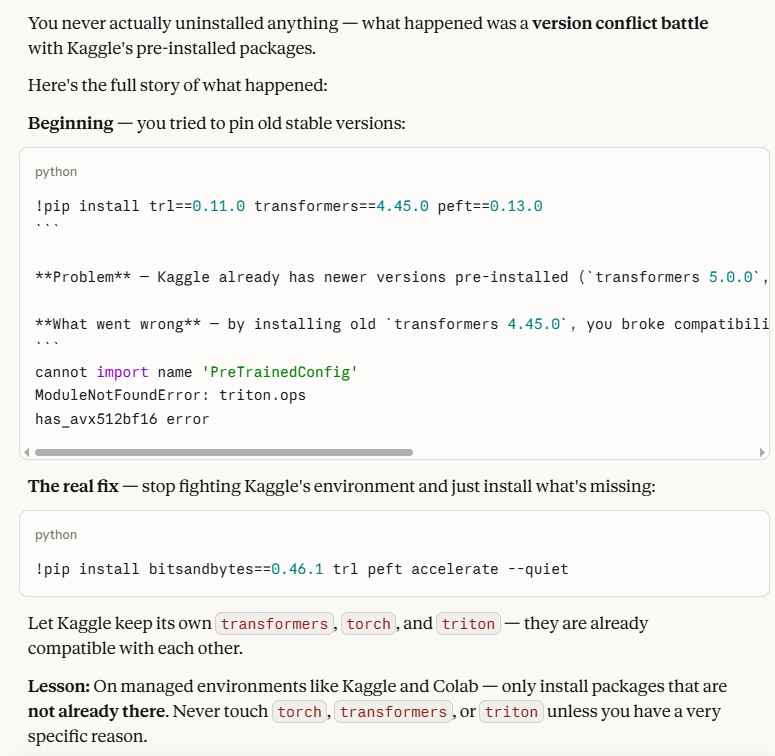

In [34]:
import numpy as np
import torch
import transformers
import trl
import peft

print("numpy:", np.__version__)
print("transformers:", transformers.__version__)
print("trl:", trl.__version__)
print("peft:", peft.__version__)

numpy: 2.0.2
transformers: 5.0.0
trl: 0.29.1
peft: 0.18.1


In [35]:
! nvidia-smi

Fri Mar 27 11:59:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [36]:
import triton
print(triton.__version__)

3.6.0


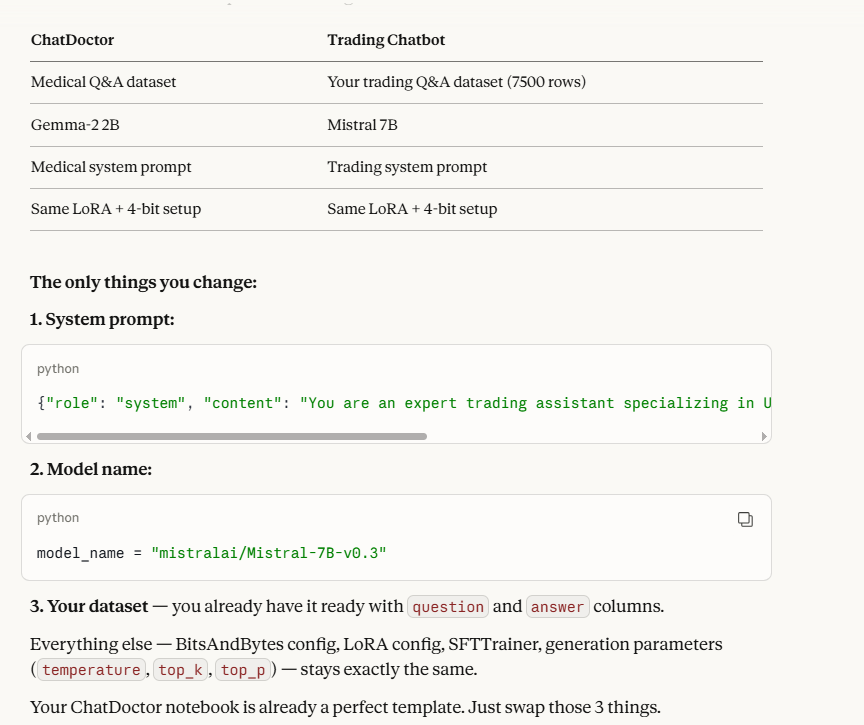

In [37]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, TrainingArguments, logging
from transformers import PreTrainedModel
from datasets import load_dataset
from peft import LoraConfig, get_peft_model
from trl import SFTTrainer
from huggingface_hub import login
import bitsandbytes as bnb
import torch

In [ ]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()


In [39]:

base_model = "mistralai/Mistral-7B-Instruct-v0.3"  
new_model = "trading_chatbot"  

# "flash_attention_2" and  "eager" are attention mechanisms
if torch.cuda.get_device_capability()[0] >= 8: 
   torch_dtype = torch.bfloat16 
   attn_implementation = "flash_attention_2"  
else:
   torch_dtype = torch.float16  
   attn_implementation = "eager"  

bnb_config = BitsAndBytesConfig(
   load_in_4bit=True, 
   bnb_4bit_quant_type="nf4", # Use normalized float 4 quantization for better quality
   bnb_4bit_compute_dtype=torch_dtype,  
   bnb_4bit_use_double_quant=True)

In [ ]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()


In [ ]:
from huggingface_hub import login



In [42]:
!pip install --upgrade huggingface_hub
from huggingface_hub import notebook_login

notebook_login()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.2/625.2 kB 11.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 77.7 MB/s eta 0:00:00:00:01
  Attempting uninstall: hf-xet
    Found existing installation: hf-xet 1.3.0
    Uninstalling hf-xet-1.3.0:
      Successfully uninstalled hf-xet-1.3.0
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1


In [43]:
import bitsandbytes
print(bitsandbytes.__version__)

0.46.1


In [44]:
!pip install bitsandbytes==0.46.1 --quiet

In [45]:
import bitsandbytes
print(bitsandbytes.__version__)

0.46.1


In [46]:

model = AutoModelForCausalLM.from_pretrained(
  base_model,                          
  quantization_config=bnb_config,      
  device_map="auto",  # Automatically manage model placement across available GPUs/CPU                 
  attn_implementation=attn_implementation)

tokenizer = AutoTokenizer.from_pretrained(base_model, trust_remote_code=True)


# This function identifies all linear layers in the model that should be modified with LoRA
def find_all_linear_names(model):
  cls = bnb.nn.Linear4bit               
  lora_module_names = set()              

  # Iterate through all named modules in the model
  for name, module in model.named_modules():
      if isinstance(module, cls):       
          names = name.split('.')      
          if len(names) == 1:          
              lora_module_names.add(names[0])
          else:                      
              lora_module_names.add(names[-1])  

  lora_module_names.discard('lm_head')   
  return list(lora_module_names)        


# Get the list of modules that will be fine-tuned using LoRA
modules = find_all_linear_names(model)
print(modules)

config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

['v_proj', 'k_proj', 'q_proj', 'gate_proj', 'o_proj', 'up_proj', 'down_proj']


In [47]:

from peft import LoraConfig, get_peft_model

peft_config = LoraConfig(
   r=32,
   lora_alpha=64,
   lora_dropout=0.05,
   bias="none",
   task_type="CAUSAL_LM",
   target_modules=modules)


# setup chat format o'rniga pasda chat_template ishlatdm 
# def setup_chat_format(model, tokenizer):
#     """
#     trl kutubxonasidagi setup_chat_format funksiyasining o'rnini bosuvchi manual funksiya.
#     """
#     special_tokens = {"additional_special_tokens": ["<|im_start|>", "<|im_end|>"]}
#     tokenizer.add_special_tokens(special_tokens)

#     model.resize_token_embeddings(len(tokenizer))

#     tokenizer.chat_template = "{% for message in messages %}{{'<|im_start|>' + message['role'] + '\n' + message['content'] + '<|im_end|>' + '\n'}}{% endfor %}"

#     model.config.chat_template = tokenizer.chat_template

#     print("Chat formati muvaffaqiyatli sozlandi!")
#     return model, tokenizer

model = get_peft_model(model, peft_config)

In [48]:

import re
from datasets import load_dataset
from transformers import AutoTokenizer


tokenizer.chat_template = (
    "{{ bos_token }}"
    "{% for message in messages %}"
    "{% if (message['role'] == 'system') %}{{ '[INST] ' + message['content'] + '\n\n' }}{% endif %}"
    "{% if (message['role'] == 'user') %}{{ message['content'] + ' [/INST] ' }}{% endif %}"
    "{% if (message['role'] == 'assistant') %}{{ message['content'] + eos_token }}{% endif %}" # eos_token =  End of Sequence token 
    "{% endfor %}")


full_dataset_hf = full_dataset_hf.shuffle(seed=42)
print(full_dataset_hf[0])  
print(full_dataset_hf.column_names)
# ['instruction', 'input', 'output']


def clean_text(text):
   text = re.sub(r'\b(?:www\.[^\s]+|http\S+)', '', text)
   text = re.sub(r'\b((?:.com)?(?:.in)?|www\.(?:google|yahoo)\S*)', '', text)
   text = re.sub(r'\s+', ' ', text)
   return text.strip()
    
def format_chat_template(row):
    cleaned_question = clean_text(row["question"])
    cleaned_answer = clean_text(row["answer"])
    
    row_json = [
        {"role": "system", "content": "You are an expert trading assistant specializing in US stock market analysis."},
        {"role": "user", "content": cleaned_question},
        {"role": "assistant", "content": cleaned_answer}
    ]
    
    row["text"] = tokenizer.apply_chat_template(row_json, tokenize=False)
    return row


full_dataset_hf = full_dataset_hf.map(format_chat_template, num_proc=4)
full_dataset_hf = full_dataset_hf.train_test_split(test_size=0.1)
# data_collator = lambda batch: tokenizer(batch["text"], return_tensors="pt", padding=True, truncation=True)


#lambda batch: tokenizer(
#     batch["text"],        # take the "text" column from the batch
#     return_tensors="pt",  # convert to PyTorch tensors
#     padding=True,         # pad short sentences
#     truncation=True       # cut long sentences
# )

{'question': 'What measures are taken to ensure the security and integrity of adaptive trading algorithms?', 'answer': 'Security measures include encryption of sensitive data, access controls, regular audits, and monitoring for anomalies or suspicious activities to protect the algorithm from unauthorized access or manipulation.', '__index_level_0__': 1917}
['question', 'answer', '__index_level_0__']


Map (num_proc=4):   0%|          | 0/7516 [00:00<?, ? examples/s]

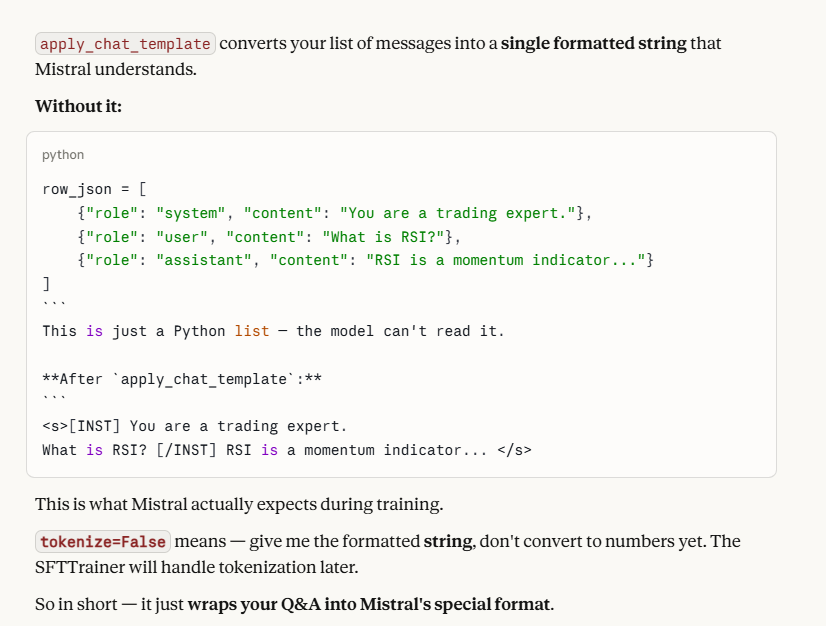

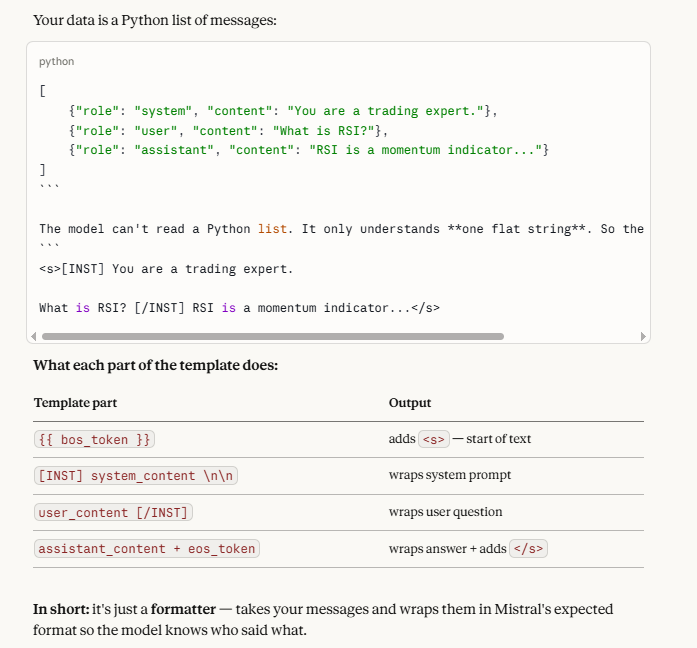

In [49]:
training_args = TrainingArguments(
    output_dir=new_model,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=2,
    optim="paged_adamw_32bit",
    max_steps=2000,
    eval_strategy="steps",
    eval_steps=200,
    save_steps=200,
    logging_steps=1,
    warmup_steps=10,
    logging_strategy="steps",
    learning_rate=0.0001, # learning_rate=1e-4
    fp16=False,
    bf16=True,
    group_by_length=True,
    load_best_model_at_end=True,
    report_to=[]
)
#  fp16=True, bf16=False  Only one can be True at a time. fp16 for older GPUs, bf16 for newer.
# group_by_length=True    Groups examples of similar length together in batches:
# report_to=[]            don't report anywhere, keep it local 


trainer = SFTTrainer(
    model=model,
    train_dataset=full_dataset_hf["train"],
    eval_dataset=full_dataset_hf["test"],
    processing_class=tokenizer,
    args=training_args)

model.config.use_cache = False

# effective_batch_size = per_device_train_batch_size × gradient_accumulation_steps

Adding EOS to train dataset:   0%|          | 0/6764 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/6764 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/6764 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/752 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/752 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/752 [00:00<?, ? examples/s]

In [50]:


# 1. Train
trainer.train()

# 2. Save locally
model.save_pretrained("./final_model")
tokenizer.save_pretrained("./final_model")


Step,Training Loss,Validation Loss
200,0.765710,1.034036
400,1.039694,0.961219
600,1.099364,0.929773
800,0.942582,0.906251
1000,0.697984,0.910428
1200,0.649024,0.901735
1400,0.719023,0.887737
1600,0.679132,0.870159
1800,0.500707,0.951331
2000,0.458906,0.948684


('./final_model/tokenizer_config.json',
 './final_model/chat_template.jinja',
 './final_model/tokenizer.json')

In [51]:

merged_model = model.merge_and_unload() # explanation below with screenshot 
merged_model.save_pretrained(new_model)
model.push_to_hub("Xasan01/mistral-trading-chatbot")
tokenizer.push_to_hub("Xasan01/mistral-trading-chatbot")


# merged_model.push_to_hub(new_model, use_temp_dir=False)

/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/bnb.py:397: UserWarning: Merge lora module to 4-bit linear may get different generations due to rounding errors.
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/Xasan01/mistral-trading-chatbot/commit/3cf74591527a6acdf6a47c595d134788f65890d9', commit_message='Upload tokenizer', commit_description='', oid='3cf74591527a6acdf6a47c595d134788f65890d9', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Xasan01/mistral-trading-chatbot', endpoint='https://huggingface.co', repo_type='model', repo_id='Xasan01/mistral-trading-chatbot'), pr_revision=None, pr_num=None)

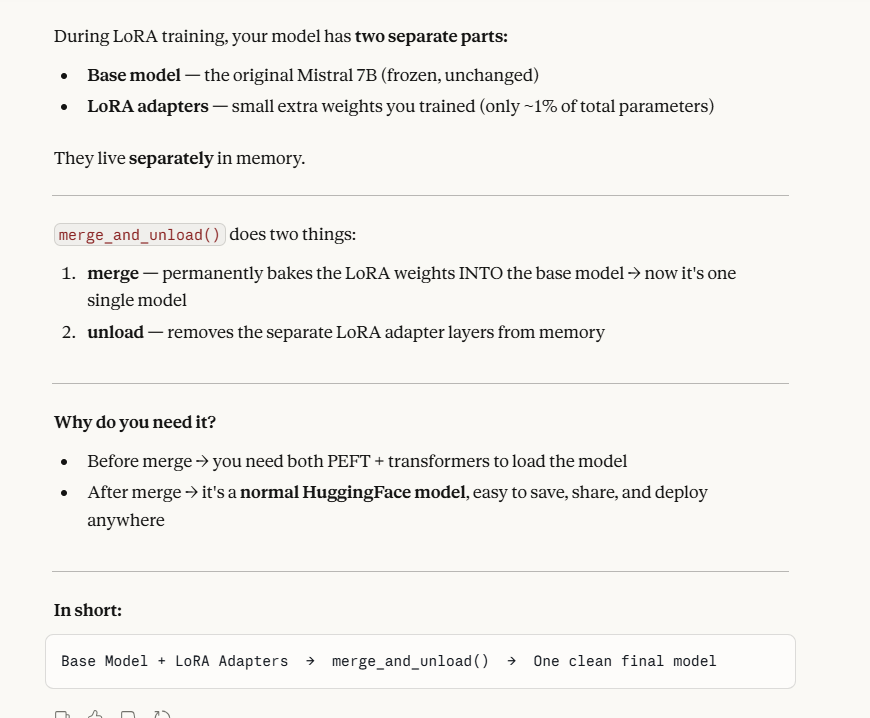

In [52]:
# 1 chi marta test qivommiz 

from transformers import GenerationConfig

tokenizer.pad_token = tokenizer.eos_token

messages = [
    {"role": "system", "content": "You are an expert trading assistant specializing in US stock market analysis."},
    {"role": "user", "content": "what is RSI and explain more specific with examples"}
]

prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = tokenizer(prompt, return_tensors='pt', padding=True, truncation=True).to("cuda")

#__________________________________________________________________

# apply_chat_template function shunaqa structure qiberadi below 
#    row_json = [
#     {"role": "user", "content": f"{cleaned_instruction}\n\n{cleaned_input}"},
#     {"role": "assistant", "content": cleaned_output}
# ]
#    row["text"] = tokenizer.apply_chat_template(row_json, tokenize=False)


# add_generation_prompt = True → adds <|im_start|>assistant at the end, telling the model "now it's your turn to speak"

#________________________________________________________________
#                                                            TRAIN PROCESSESS


outputs = model.generate(
    **inputs,
    max_length=700,             # stop after 350 tokens
    top_k=50,                   # only consider top 50 words at each step
    top_p=0.9,                 # only consider words covering 85% probability
    do_sample=True, 
    temperature=0.2,            # how creative/random the answer is
    no_repeat_ngram_size=3, 
    repetition_penalty=1.2 # never repeat same 3 words
)

response = tokenizer.decode(outputs[0], skip_special_tokens=True).split("assistant")[-1].strip()
response = response.split("[/INST]")[-1].strip()

print(response)

#____________________________________________________________________

# temperature=0.0  →  [99%, 1%, 0%, 0%]   → always same word, robotic 🤖
# temperature=0.3  →  [85%, 12%, 2%, 1%]  → focused, factual ✅ (our case)
# temperature=1.0  →  [40%, 30%, 20%, 10%] → balanced, natural
# temperature=1.5  →  [25%, 22%, 20%, 18%] → creative, risky 🎨
# temperature=2.0  →  [26%, 25%, 25%, 24%] → almost random, nonsense 😵

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


specializing in US stock market analysis.

what is RSI and explain more specific with examples  1) Relative Strength Index (RSI): A momentum oscillator that measures the speed and change of price movements. Values above 70dicate overbought conditions, while values below 30 suggest oversold conditions. For example, if a stock's RSI reads 85, it may signal a potential reversal or correction.


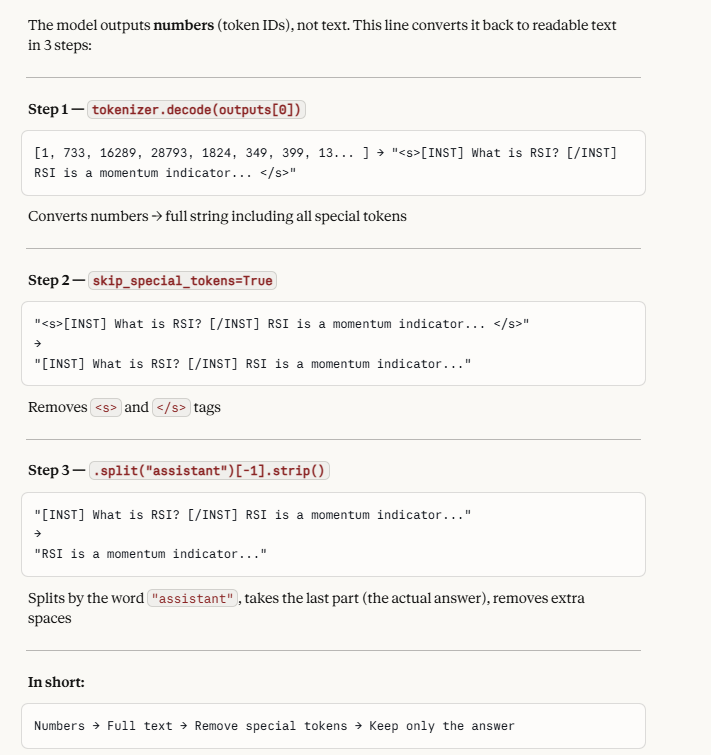

In [53]:
# 2 chi marta test qivommiz 

from transformers import GenerationConfig

tokenizer.pad_token = tokenizer.eos_token
messages = [
    {"role": "system", "content": "You are an expert trading assistant specializing in US stock market analysis."},
    {"role": "user", "content": "what is RSI and explain more specific with examples"}
]

prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = tokenizer(prompt, return_tensors='pt', padding=True, truncation=True).to("cuda")



outputs = model.generate(
    **inputs,
    max_length=700,
    top_k=50,
    top_p=0.9,
    do_sample=True, 
    temperature=0.2,  
    no_repeat_ngram_size=3,
    repetition_penalty=1.2
)

response = tokenizer.decode(outputs[0], skip_special_tokens=True).split("assistant")[-1].strip()
response = response.split("[/INST]")[-1].strip()

print(response)


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


specializing in US stock market analysis.

what is RSI and explain more specific with examples  1) Relative Strength Index (RSI): A momentum oscillator that measures the speed and change of price movements. Values above 70dicate overbought conditions, while values below 30 suggest oversold conditions. For example, if a stock's RSIdicates overbougthigh levels, it may signal a potential reversal or correction.


In [55]:
import gradio as gr

def chat(message, history):
    tokenizer.pad_token = tokenizer.eos_token
    messages = [
        {"role": "system", "content": "You are an expert trading assistant specializing in US stock market analysis, technical analysis, and fundamental analysis."},
        {"role": "user", "content": message}
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    outputs = model.generate(
        **inputs,
        max_length=700,
        do_sample=True,
        temperature=0.2,
        top_p=0.9,
        top_k=50,
        repetition_penalty=1.2,
        no_repeat_ngram_size=3,
    )
    response = tokenizer.decode(outputs[0], skip_special_tokens=True).split("assistant")[-1].strip()
    response = response.split("[/INST]")[-1].strip()
    return response

gr.ChatInterface(
    fn=chat,
    title="📈 Trading Assistant",
    description="Ask me anything about stocks, technical analysis, RSI, MACD, and more.",
    examples=[
        "What is RSI and how do I use it?",
        "Explain MACD with an example",
        "What is the difference between support and resistance?",
        "How does dollar-cost averaging work?",
    ],
    theme=gr.themes.Soft()).launch(share=True)

/usr/local/lib/python3.12/dist-packages/gradio/chat_interface.py:347: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://a64b08591f484906eb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


In [1]:


# LOAD THE MODEL 

from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

model_name = "Xasan01/mistral-trading-chatbot"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

tokenizer_config.json:   0%|          | 0.00/431 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

chat_template.jinja:   0%|          | 0.00/321 [00:00<?, ?B/s]

adapter_config.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/40.0 [00:00<?, ?B/s]

Loading weights: 0it [00:00, ?it/s]

MistralForCausalLM LOAD REPORT from: Xasan01/mistral-trading-chatbot
Key                                                          | Status  | 
-------------------------------------------------------------+---------+-
model.layers.{0...31}.self_attn.k_proj.lora_B.default.weight | MISSING | 
model.layers.{0...31}.mlp.gate_proj.lora_B.default.weight    | MISSING | 
model.layers.{0...31}.mlp.down_proj.lora_A.default.weight    | MISSING | 
model.layers.{0...31}.self_attn.q_proj.lora_A.default.weight | MISSING | 
model.layers.{0...31}.self_attn.v_proj.lora_B.default.weight | MISSING | 
model.layers.{0...31}.mlp.up_proj.lora_A.default.weight      | MISSING | 
model.layers.{0...31}.mlp.down_proj.lora_B.default.weight    | MISSING | 
model.layers.{0...31}.mlp.gate_proj.lora_A.default.weight    | MISSING | 
model.layers.{0...31}.self_attn.v_proj.lora_A.default.weight | MISSING | 
model.layers.{0...31}.self_attn.q_proj.lora_B.default.weight | MISSING | 
model.layers.{0...31}.self_attn.o_proj.lora

In [2]:
# TO CHECK AFTER UPLOADED MY MODEL FROM HUGGING FACE 

import gradio as gr

def chat(message, history):
    tokenizer.pad_token = tokenizer.eos_token
    messages = [
        {"role": "system", "content": "You are an expert trading assistant specializing in US stock market analysis, technical analysis, and fundamental analysis."},
        {"role": "user", "content": message}
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    outputs = model.generate(
        **inputs,
        max_length=700,
        do_sample=True,
        temperature=0.2,
        top_p=0.9,
        top_k=50,
        repetition_penalty=1.2,
        no_repeat_ngram_size=3,
    )
    response = tokenizer.decode(outputs[0], skip_special_tokens=True).split("assistant")[-1].strip()
    response = response.split("[/INST]")[-1].strip()
    return response

gr.ChatInterface(
    fn=chat,
    title="📈 Trading Assistant",
    description="Ask me anything about stocks, technical analysis, RSI, MACD, and more.",
    examples=[
        "What is RSI and how do I use it?",
        "Explain MACD with an example",
        "What is the difference between support and resistance?",
        "How does dollar-cost averaging work?",
    ],
    theme=gr.themes.Soft()).launch(share=True)

/usr/local/lib/python3.12/dist-packages/gradio/chat_interface.py:347: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://c925f8b73bfd3ef360.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


In [ ]:
# User → Telegram Bot → HuggingFace Inference API → Your Model → Response → Telegram

In [2]:
# TELEGRAM BOT CODE

# ! pip install python-telegram-bot gradio_client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 745.4/745.4 kB 16.9 MB/s eta 0:00:0000:01


In [10]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("chatbot")
print(secret_value_0)

<REDACTED>


In [13]:
# import requests
# import nest_asyncio
# from telegram import Update
# from telegram.ext import ApplicationBuilder, MessageHandler, filters, ContextTypes


# telegram_token = "<REDACTED>"
# API_URL = "https://router.huggingface.co/models/Xasan01/mistral-trading-chatbot"
# headers = {"Authorization": "<REDACTED>"}

# def ask_model(question):
#     prompt = f"[INST] You are an expert trading assistant.\n\n{question} [/INST]"
#     response = requests.post(API_URL, headers=headers, json={
#         "inputs": prompt,
#         "parameters": {
#             "max_new_tokens": 400,
#             "temperature": 0.2,
#             "top_p": 0.9,
#             "repetition_penalty": 1.2}
#     })
#     print(response.status_code) 
#     print(response.text) 
#     result = response.json()
#     print(result)
#     return result[0]["generated_text"].split("[/INST]")[-1].strip()

# async def error_handler(update, context):
#     print(f"Error: {context.error}")


# async def handle_message(update: Update, context: ContextTypes.DEFAULT_TYPE):
#     user_message = update.message.text
#     response = ask_model(user_message)
#     await update.message.reply_text(response)


# nest_asyncio.apply()
# app.add_error_handler(error_handler)  
# app = ApplicationBuilder().token(telegram_token).build()
# app.add_handler(MessageHandler(filters.TEXT, handle_message))
# app.run_polling()

ERROR:telegram.ext.Application:No error handlers are registered, logging exception.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/requests/models.py", line 976, in json
    return complexjson.loads(self.text, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/simplejson/__init__.py", line 514, in loads
    return _default_decoder.decode(s)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/simplejson/decoder.py", line 386, in decode
    obj, end = self.raw_decode(s)
               ^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/simplejson/decoder.py", line 416, in raw_decode
    return self.scan_once(s, idx=_w(s, idx).end())
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
simplejson.errors.JSONDecodeError: Expecting value: line 1 column 1 (char 0)

During handling of the above exception, another exception occurred:

Traceback (most recen

404
Not Found


RuntimeError: Cannot close a running event loop

In [ ]:
# https://api-inference.huggingface.co/models/ + YOUR_MODEL_NAME

# huggingface.co/... → opens the model page in browser
# api-inference.huggingface.co/models/... → sends requests to the model


# Run the bot code on Kaggle first 
# Then go to Telegram and send a message to @xasan_trading_chat_bot